# 삼성전자 EDA: 종가 추이 & 기관/외국인 순매수 분석
- **기간**: 2023-01-02 ~ 2025-12-31
- **데이터**: OHLCV + unified_data (기관/외국인 순매수)

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

## 1. 데이터 로드 & 전처리

In [20]:
# OHLCV 데이터 로드
ohlcv = pd.read_csv('OHLCV_20230102_20251231.csv', parse_dates=['date'])
samsung_ohlcv = ohlcv[ohlcv['ticker'] == 'A005930'].copy()
samsung_ohlcv.set_index('date', inplace=True)
samsung_ohlcv.sort_index(inplace=True)

# unified_data (기관/외국인 순매수) 로드
unified = pd.read_csv('unified_data.csv', parse_dates=['date'])
samsung_uni = unified[unified['ticker'] == 'A005930'].copy()
samsung_uni.set_index('date', inplace=True)
samsung_uni.sort_index(inplace=True)

# 병합
df = samsung_ohlcv[['종가', '거래량']].join(samsung_uni[['inst_net_buy', 'foreign_net_buy']], how='inner')
df.columns = ['종가', '거래량', '기관순매수', '외국인순매수']

print(f'데이터 기간: {df.index.min().date()} ~ {df.index.max().date()}')
print(f'총 거래일: {len(df)}일')
df.head()

데이터 기간: 2023-01-02 ~ 2025-12-30
총 거래일: 729일


,종가,거래량,기관순매수,외국인순매수
date,,,,
2023-01-02,55500,10031448,-26810406100,-33675372900
2023-01-03,55400,13547030,-86326446000,17424799500
2023-01-04,57800,20188071,-8643145700,176119473500
2023-01-05,58200,15682826,-129221395200,204733901700
2023-01-06,59000,17334989,24193018400,135516386600


In [21]:
df.describe()

,종가,거래량,기관순매수,외국인순매수
count,729.000000,7.290000e+02,7.290000e+02,7.290000e+02
mean,70119.067215,1.819553e+07,-1.774426e+09,2.196188e+10
std,12913.217575,8.127716e+06,1.682223e+11,2.874453e+11
min,49900.000000,5.824628e+06,-2.273992e+12,-1.224837e+12
25%,60400.000000,1.236509e+07,-6.805227e+10,-1.002261e+11
50%,69600.000000,1.610831e+07,-7.170872e+09,9.355754e+09
75%,75200.000000,2.206148e+07,6.158287e+10,1.254414e+11
max,119900.000000,5.769127e+07,6.473690e+11,1.795039e+12


## 2. 삼성전자 종가 추이

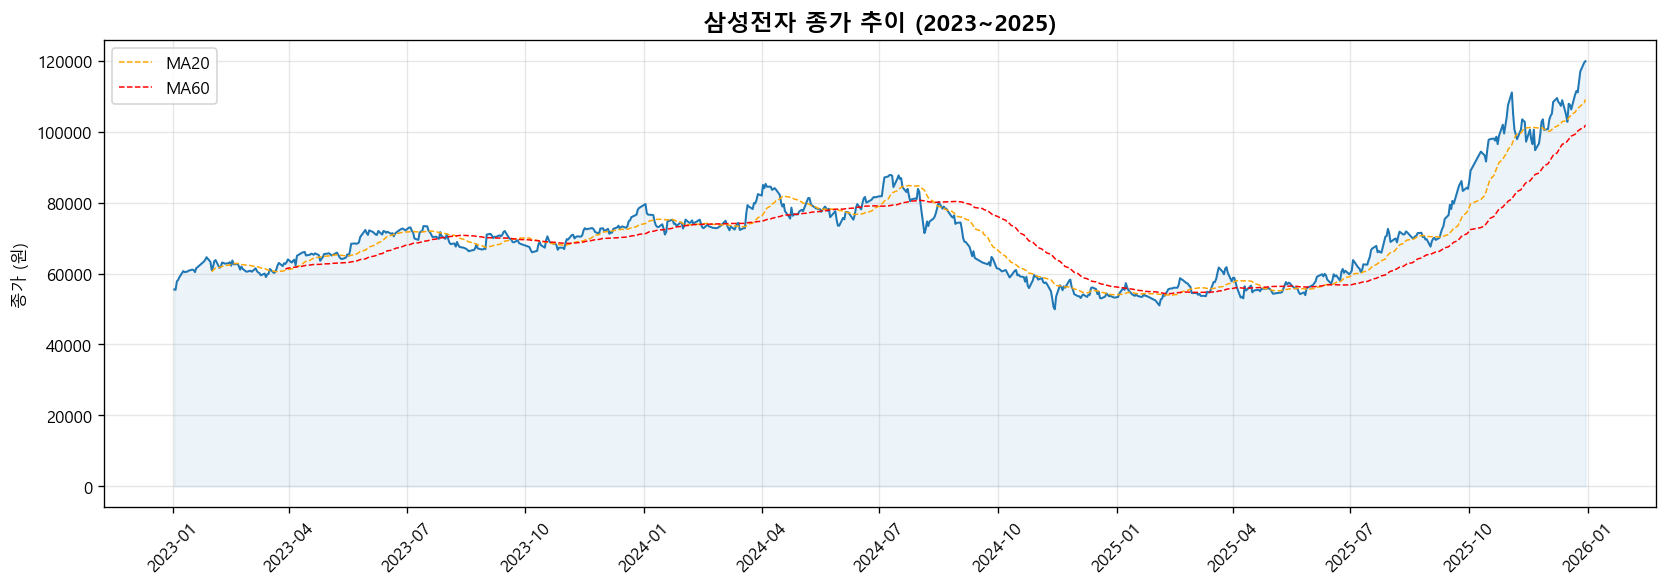

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['종가'], color='#1f77b4', linewidth=1.2)
ax.fill_between(df.index, df['종가'], alpha=0.08, color='#1f77b4')

# 20일/60일 이동평균
ma20 = df['종가'].rolling(20).mean()
ma60 = df['종가'].rolling(60).mean()
ax.plot(df.index, ma20, '--', color='orange', linewidth=0.9, label='MA20')
ax.plot(df.index, ma60, '--', color='red', linewidth=0.9, label='MA60')

ax.set_title('삼성전자 종가 추이 (2023~2025)', fontsize=14, fontweight='bold')
ax.set_ylabel('종가 (원)')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. 거래량 추이

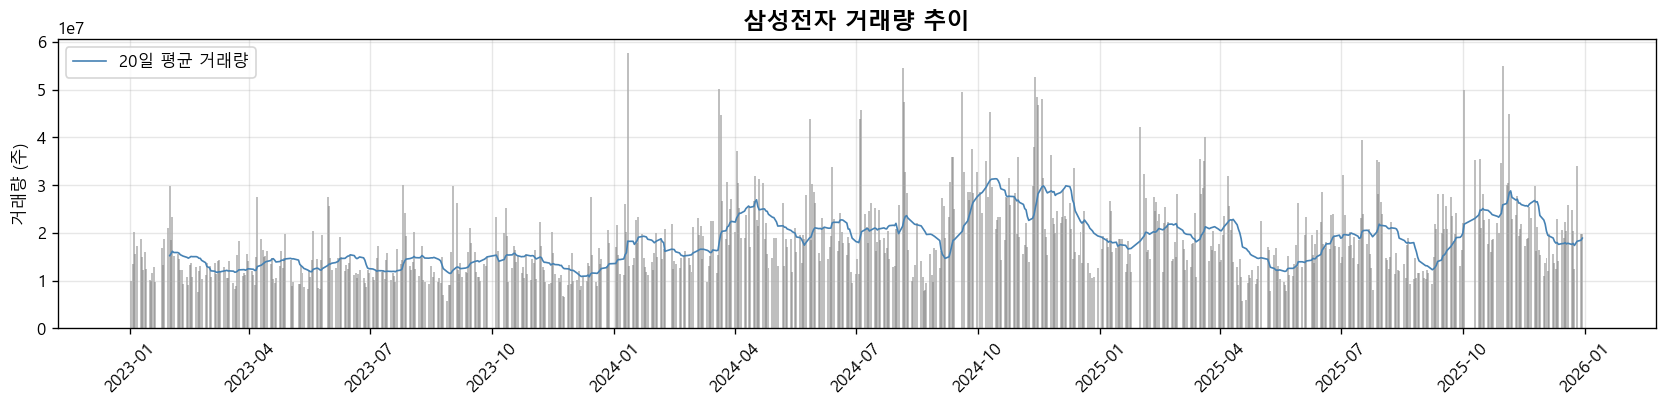

In [23]:
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.bar(df.index, df['거래량'], width=1.5, color='gray', alpha=0.5)
ax.plot(df.index, df['거래량'].rolling(20).mean(), color='steelblue', linewidth=1, label='20일 평균 거래량')

ax.set_title('삼성전자 거래량 추이', fontsize=14, fontweight='bold')
ax.set_ylabel('거래량 (주)')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. 기관 / 외국인 순매수 분석

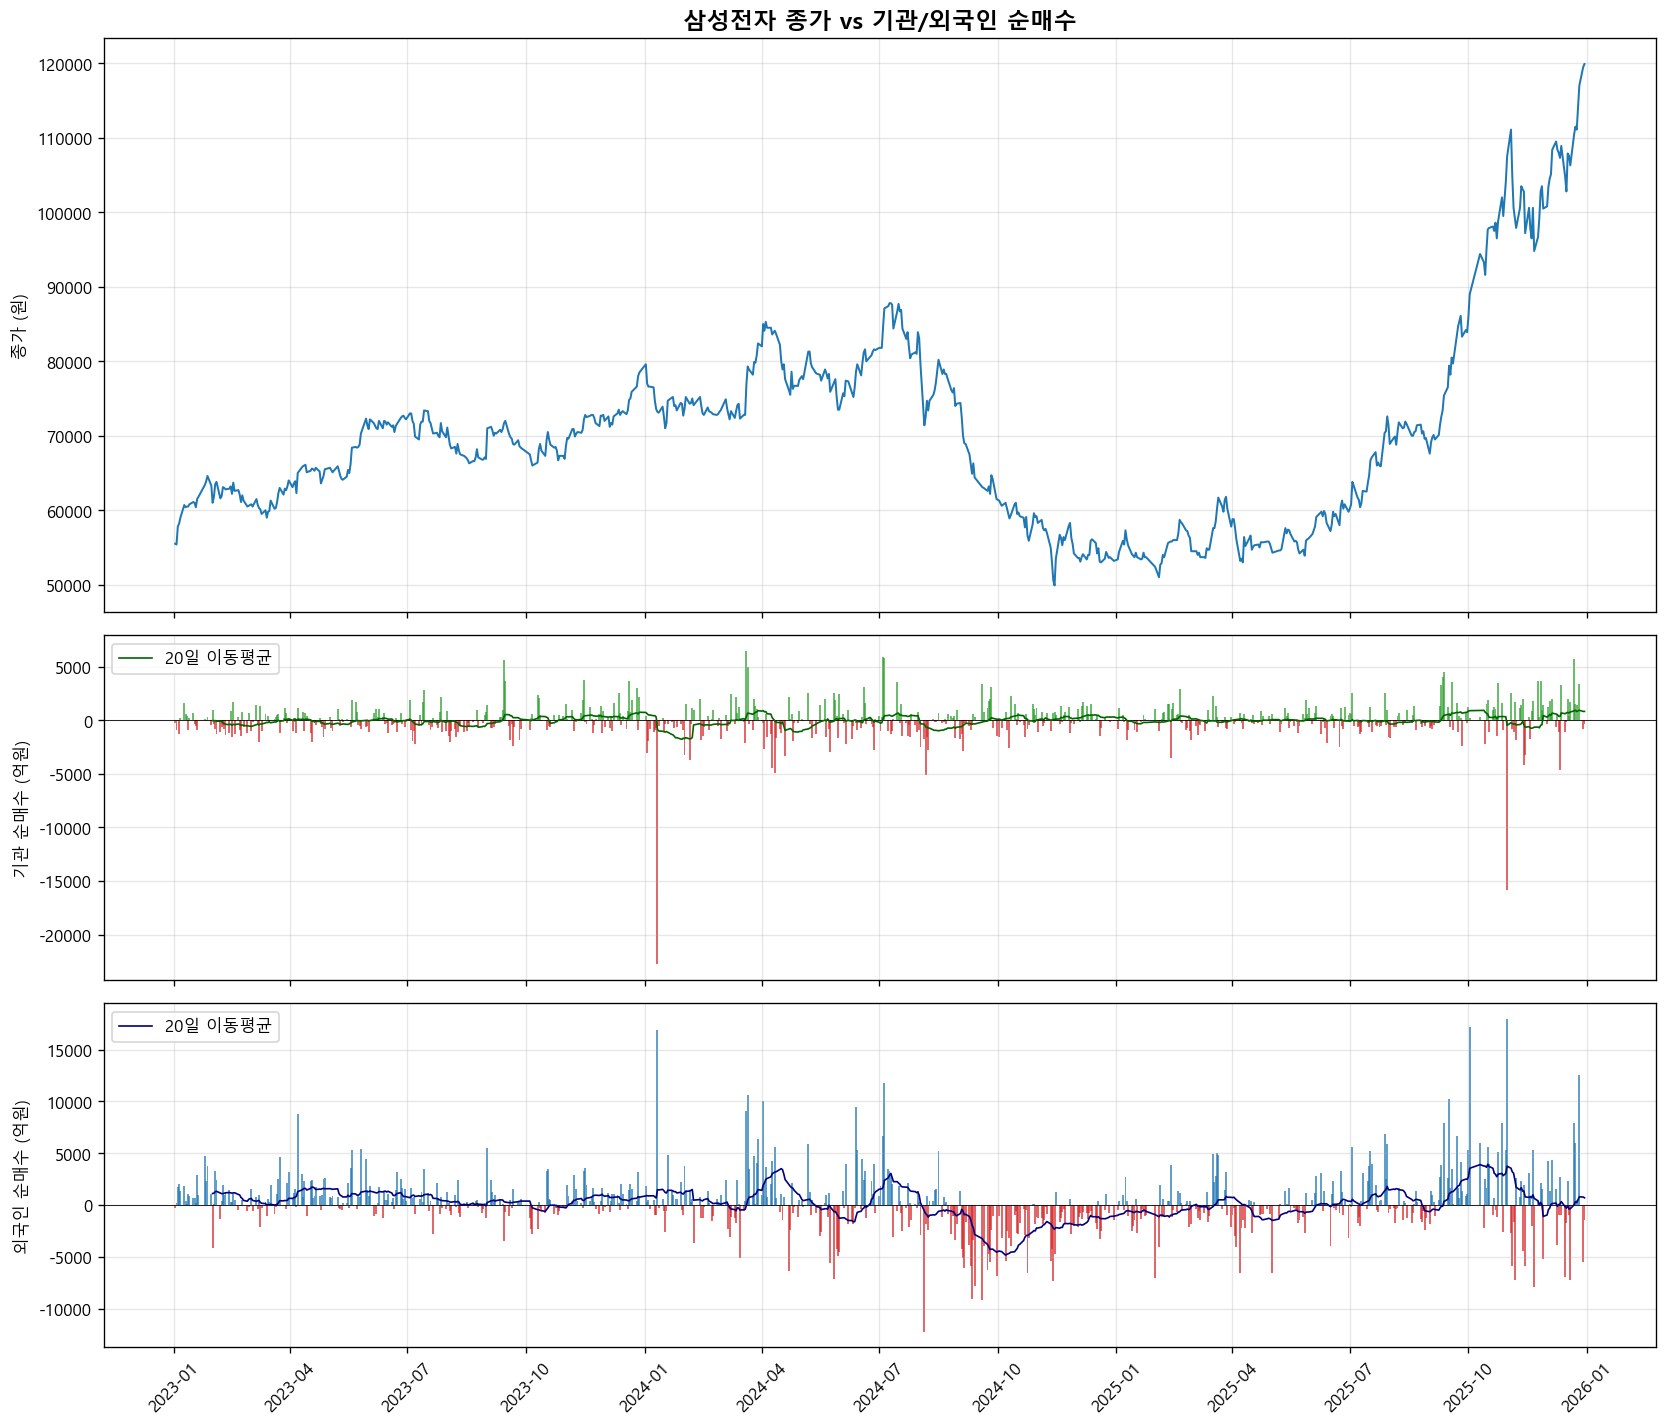

In [24]:
# 순매수 금액을 억 원 단위로 변환
df['기관순매수_억'] = df['기관순매수'] / 1e8
df['외국인순매수_억'] = df['외국인순매수'] / 1e8

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1.2, 1.2]})

# (1) 종가
axes[0].plot(df.index, df['종가'], color='#1f77b4', linewidth=1.2)
axes[0].set_title('삼성전자 종가 vs 기관/외국인 순매수', fontsize=14, fontweight='bold')
axes[0].set_ylabel('종가 (원)')
axes[0].grid(alpha=0.3)

# (2) 기관 순매수
colors_inst = ['#d62728' if v < 0 else '#2ca02c' for v in df['기관순매수_억']]
axes[1].bar(df.index, df['기관순매수_억'], width=1.5, color=colors_inst, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].plot(df.index, df['기관순매수_억'].rolling(20).mean(), color='darkgreen', linewidth=1, label='20일 이동평균')
axes[1].set_ylabel('기관 순매수 (억원)')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

# (3) 외국인 순매수
colors_for = ['#d62728' if v < 0 else '#1f77b4' for v in df['외국인순매수_억']]
axes[2].bar(df.index, df['외국인순매수_억'], width=1.5, color=colors_for, alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].plot(df.index, df['외국인순매수_억'].rolling(20).mean(), color='navy', linewidth=1, label='20일 이동평균')
axes[2].set_ylabel('외국인 순매수 (억원)')
axes[2].legend(loc='upper left')
axes[2].grid(alpha=0.3)

axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. 기관/외국인 누적 순매수 vs 종가

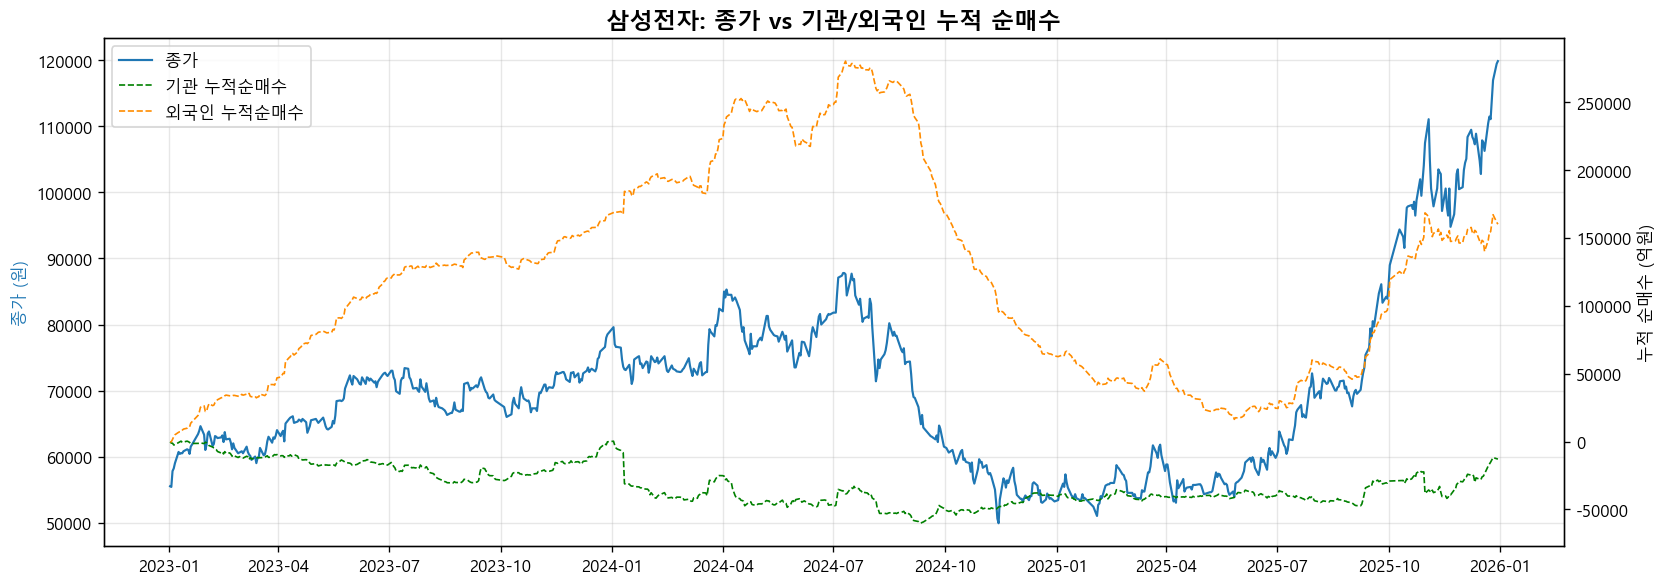

In [25]:
df['기관누적순매수_억'] = df['기관순매수_억'].cumsum()
df['외국인누적순매수_억'] = df['외국인순매수_억'].cumsum()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(df.index, df['종가'], color='#1f77b4', linewidth=1.3, label='종가')
ax2.plot(df.index, df['기관누적순매수_억'], color='green', linewidth=1, linestyle='--', label='기관 누적순매수')
ax2.plot(df.index, df['외국인누적순매수_억'], color='darkorange', linewidth=1, linestyle='--', label='외국인 누적순매수')

ax1.set_ylabel('종가 (원)', color='#1f77b4')
ax2.set_ylabel('누적 순매수 (억원)')
ax1.set_title('삼성전자: 종가 vs 기관/외국인 누적 순매수', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. 월별 순매수 히트맵

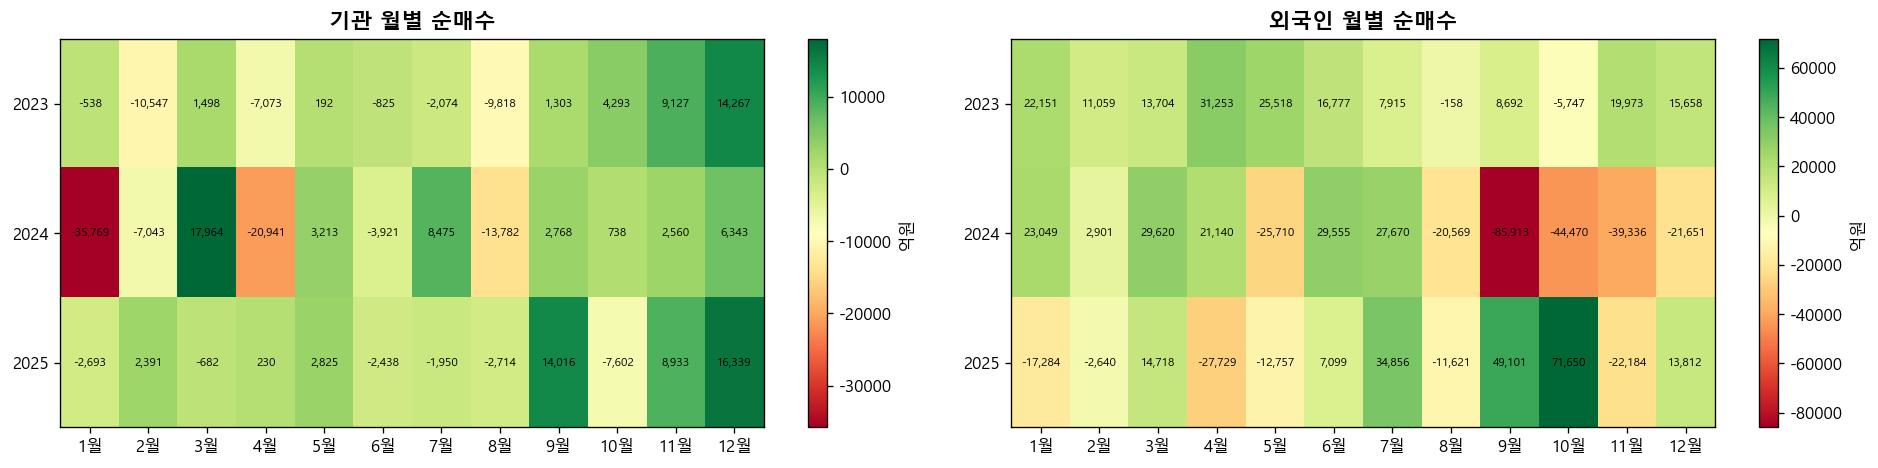

In [26]:
monthly = df[['기관순매수_억', '외국인순매수_억']].resample('ME').sum()
monthly['year'] = monthly.index.year
monthly['month'] = monthly.index.month

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

for i, (col, title) in enumerate([('기관순매수_억', '기관 월별 순매수'), ('외국인순매수_억', '외국인 월별 순매수')]):
    pivot = monthly.pivot_table(index='year', columns='month', values=col, aggfunc='sum')
    im = axes[i].imshow(pivot.values, cmap='RdYlGn', aspect='auto')
    axes[i].set_xticks(range(12))
    axes[i].set_xticklabels([f'{m}월' for m in range(1, 13)])
    axes[i].set_yticks(range(len(pivot.index)))
    axes[i].set_yticklabels(pivot.index)
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    plt.colorbar(im, ax=axes[i], label='억원')
    
    # 셀 값 표시
    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            val = pivot.values[r, c]
            if not np.isnan(val):
                axes[i].text(c, r, f'{val:,.0f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()

## 7. 기관/외국인 순매수 상관관계

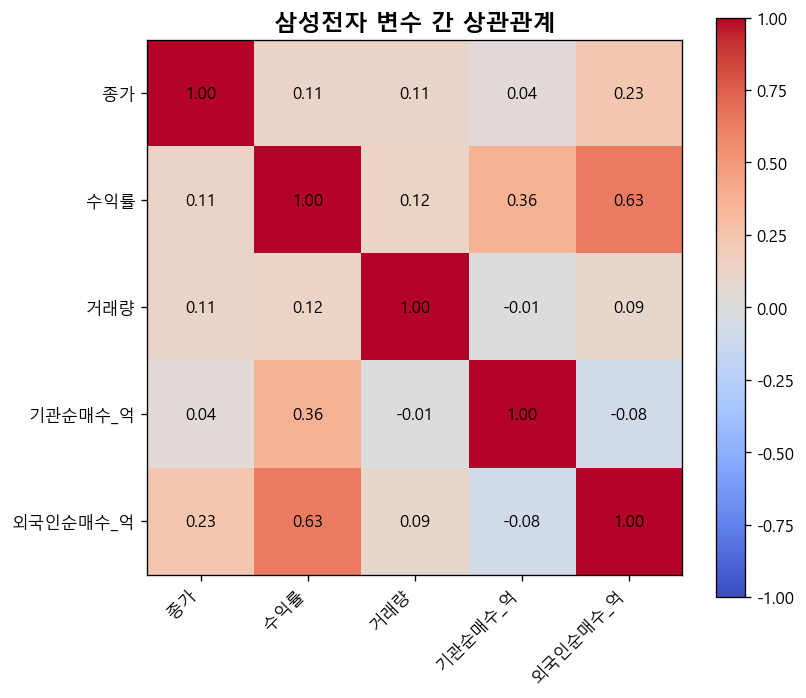

In [27]:
# 종가 수익률 계산
df['수익률'] = df['종가'].pct_change()

corr_cols = ['종가', '수익률', '거래량', '기관순매수_억', '외국인순매수_억']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)
plt.colorbar(im, ax=ax)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr_matrix.values[i, j]:.2f}', ha='center', va='center', fontsize=10)

ax.set_title('삼성전자 변수 간 상관관계', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. 순매수 구간별 수익률 분포

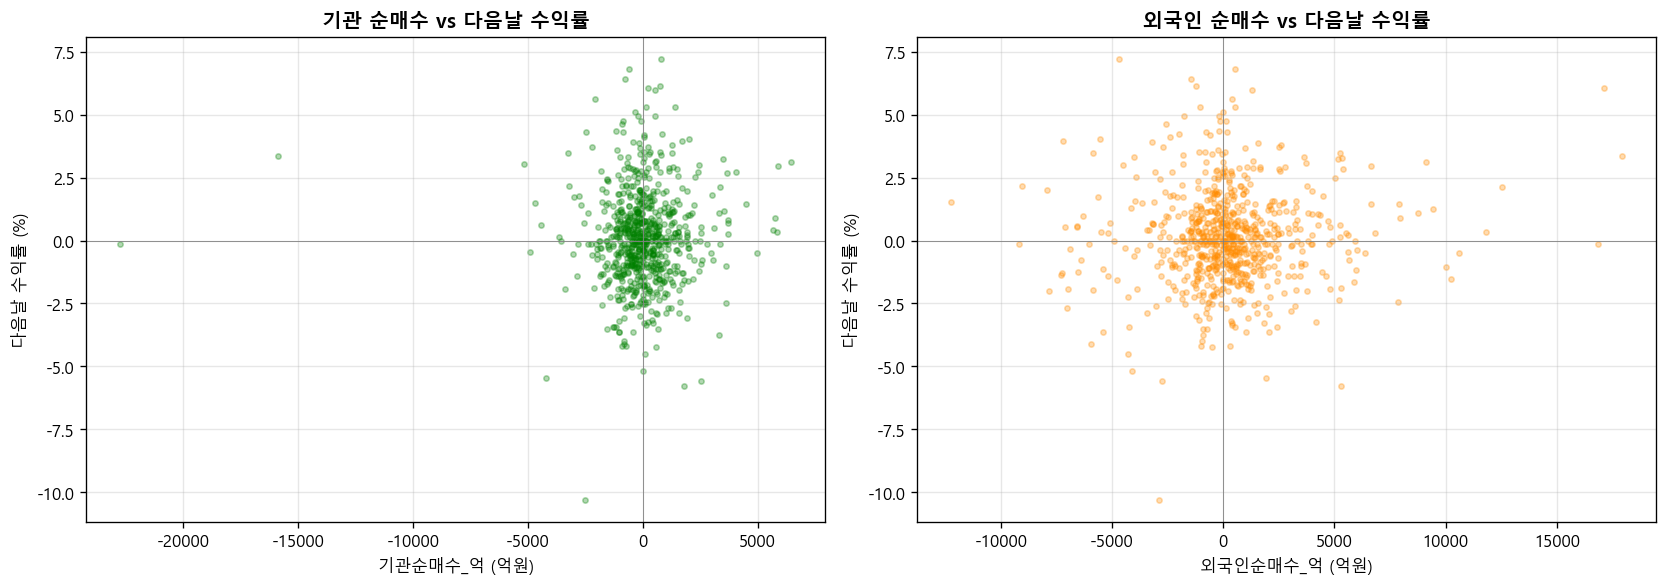

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (col, title, color) in enumerate([
    ('기관순매수_억', '기관 순매수 vs 다음날 수익률', 'green'),
    ('외국인순매수_억', '외국인 순매수 vs 다음날 수익률', 'darkorange')
]):
    df['다음날수익률'] = df['수익률'].shift(-1)
    axes[i].scatter(df[col], df['다음날수익률'] * 100, alpha=0.3, s=10, color=color)
    axes[i].axhline(0, color='gray', linewidth=0.5)
    axes[i].axvline(0, color='gray', linewidth=0.5)
    axes[i].set_xlabel(f'{col} (억원)')
    axes[i].set_ylabel('다음날 수익률 (%)')
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. 요약 통계

In [29]:
print('='*60)
print('삼성전자 기관/외국인 순매수 요약')
print('='*60)
print(f"\n기간: {df.index.min().date()} ~ {df.index.max().date()}")
print(f"총 거래일: {len(df)}일")
print(f"\n종가 범위: {df['종가'].min():,.0f}원 ~ {df['종가'].max():,.0f}원")
print(f"기간 수익률: {(df['종가'].iloc[-1] / df['종가'].iloc[0] - 1) * 100:.1f}%")
print(f"\n--- 기관 ---")
print(f"  일평균 순매수: {df['기관순매수_억'].mean():,.1f}억원")
print(f"  순매수 일수: {(df['기관순매수_억'] > 0).sum()}일 / 순매도 일수: {(df['기관순매수_억'] < 0).sum()}일")
print(f"  누적 순매수: {df['기관순매수_억'].sum():,.0f}억원")
print(f"\n--- 외국인 ---")
print(f"  일평균 순매수: {df['외국인순매수_억'].mean():,.1f}억원")
print(f"  순매수 일수: {(df['외국인순매수_억'] > 0).sum()}일 / 순매도 일수: {(df['외국인순매수_억'] < 0).sum()}일")
print(f"  누적 순매수: {df['외국인순매수_억'].sum():,.0f}억원")

삼성전자 기관/외국인 순매수 요약

기간: 2023-01-02 ~ 2025-12-30
총 거래일: 729일

종가 범위: 49,900원 ~ 119,900원
기간 수익률: 116.0%

--- 기관 ---
  일평균 순매수: -17.7억원
  순매수 일수: 341일 / 순매도 일수: 388일
  누적 순매수: -12,936억원

--- 외국인 ---
  일평균 순매수: 219.6억원
  순매수 일수: 383일 / 순매도 일수: 346일
  누적 순매수: 160,102억원


## 10. 대차잔고 & 신용잔고 데이터 추가

In [30]:
# unified_data에서 대차/신용 컬럼 추가
loan_credit_cols = ['loan_new', 'loan_return', 'loan_balance_shares', 'loan_balance_amt',
                    'credit_balance_amt', 'credit_ratio']
df2 = df.join(samsung_uni[loan_credit_cols], how='inner')
df2.rename(columns={
    'loan_new': '대차체결주식수',
    'loan_return': '상환주식수',
    'loan_balance_shares': '대차잔고주식수',
    'loan_balance_amt': '대차잔고금액',
    'credit_balance_amt': '신용잔고금액',
    'credit_ratio': '신용비율'
}, inplace=True)

print(f"대차/신용 데이터 shape: {df2.shape}")
df2[['대차체결주식수', '상환주식수', '대차잔고주식수', '대차잔고금액', '신용잔고금액', '신용비율']].describe()

대차/신용 데이터 shape: (729, 16)


,대차체결주식수,상환주식수,대차잔고주식수,대차잔고금액,신용잔고금액,신용비율
count,7.290000e+02,7.290000e+02,7.290000e+02,7.290000e+02,7.290000e+02,729.000000
mean,2.396151e+06,2.441486e+06,1.196988e+08,8.295117e+12,6.348698e+07,0.156749
std,2.178808e+06,2.416066e+06,2.133412e+07,1.612356e+12,3.151844e+07,0.078522
min,3.885500e+04,3.398400e+04,8.302032e+07,5.287221e+12,2.420828e+07,0.050000
25%,9.723190e+05,9.080440e+05,1.004039e+08,6.899263e+12,3.614503e+07,0.090000
50%,1.775855e+06,1.726712e+06,1.151630e+08,8.284375e+12,5.968584e+07,0.130000
75%,3.045640e+06,3.113020e+06,1.379054e+08,9.714528e+12,8.236714e+07,0.230000
max,1.817232e+07,2.322309e+07,1.649471e+08,1.241213e+13,1.752535e+08,0.330000


## 11. 대차체결주식수 vs 상환주식수 추이

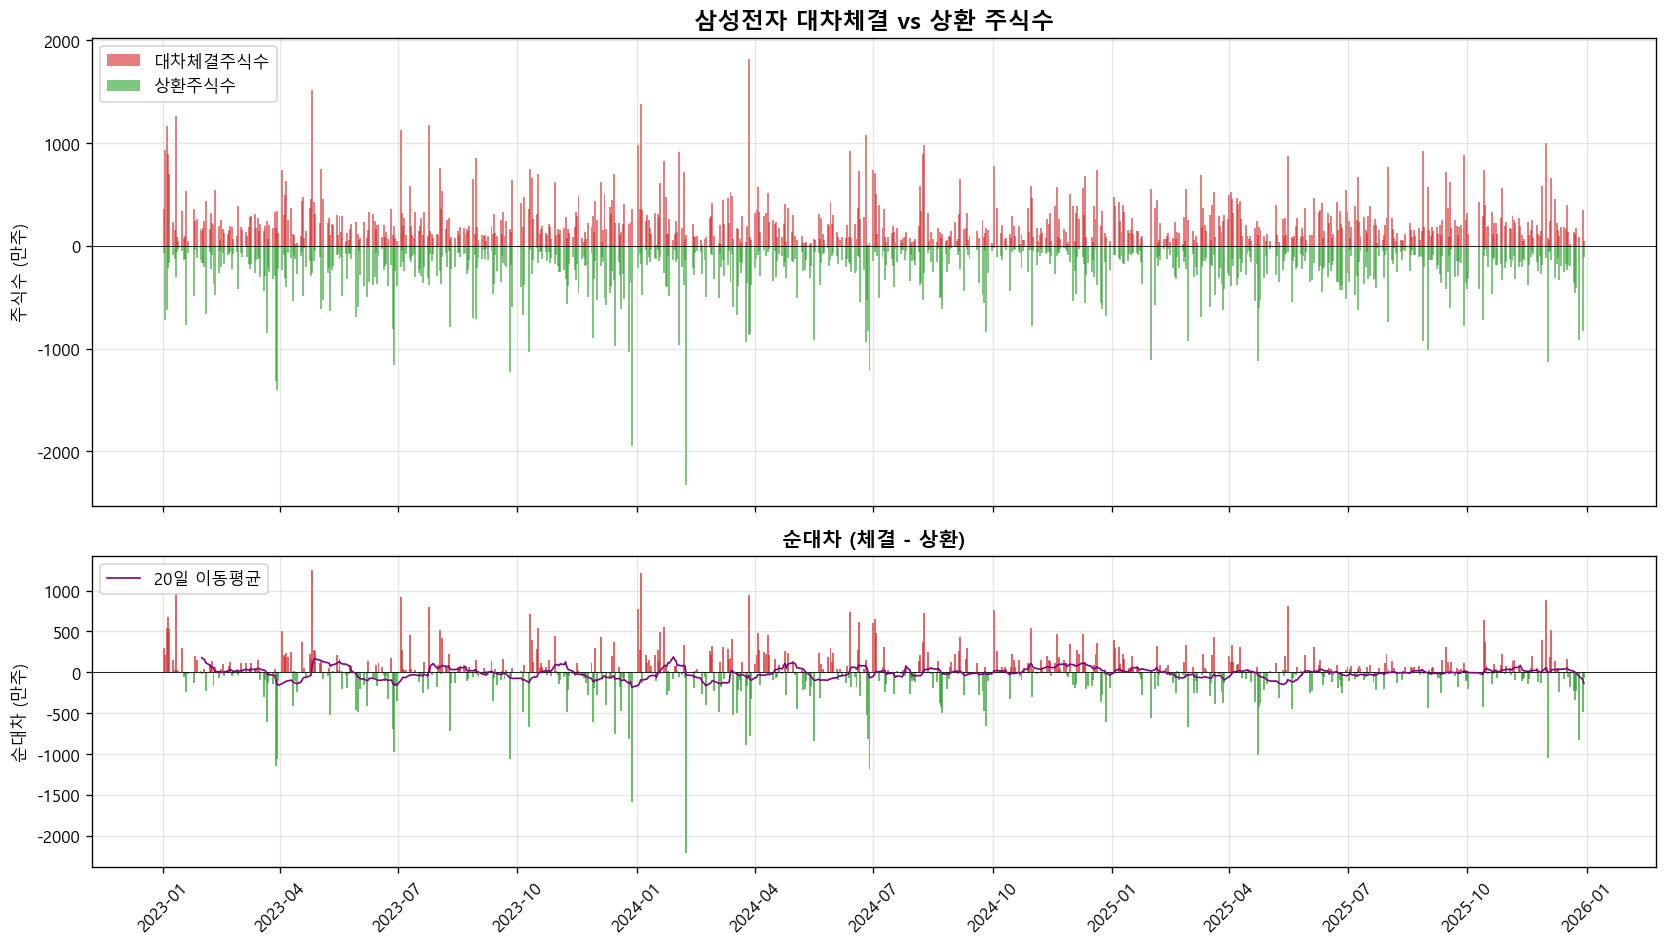

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [1.5, 1]})

# (1) 대차체결 vs 상환 주식수
axes[0].bar(df2.index, df2['대차체결주식수'] / 1e4, width=1.5, color='#d62728', alpha=0.6, label='대차체결주식수')
axes[0].bar(df2.index, -df2['상환주식수'] / 1e4, width=1.5, color='#2ca02c', alpha=0.6, label='상환주식수')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('삼성전자 대차체결 vs 상환 주식수', fontsize=14, fontweight='bold')
axes[0].set_ylabel('주식수 (만주)')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# (2) 순대차 (체결 - 상환)
net_loan = (df2['대차체결주식수'] - df2['상환주식수']) / 1e4
colors_net = ['#d62728' if v > 0 else '#2ca02c' for v in net_loan]
axes[1].bar(df2.index, net_loan, width=1.5, color=colors_net, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].plot(df2.index, net_loan.rolling(20).mean(), color='purple', linewidth=1, label='20일 이동평균')
axes[1].set_title('순대차 (체결 - 상환)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('순대차 (만주)')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 12. 대차잔고주식수 & 대차잔고금액 추이 (종가 비교)

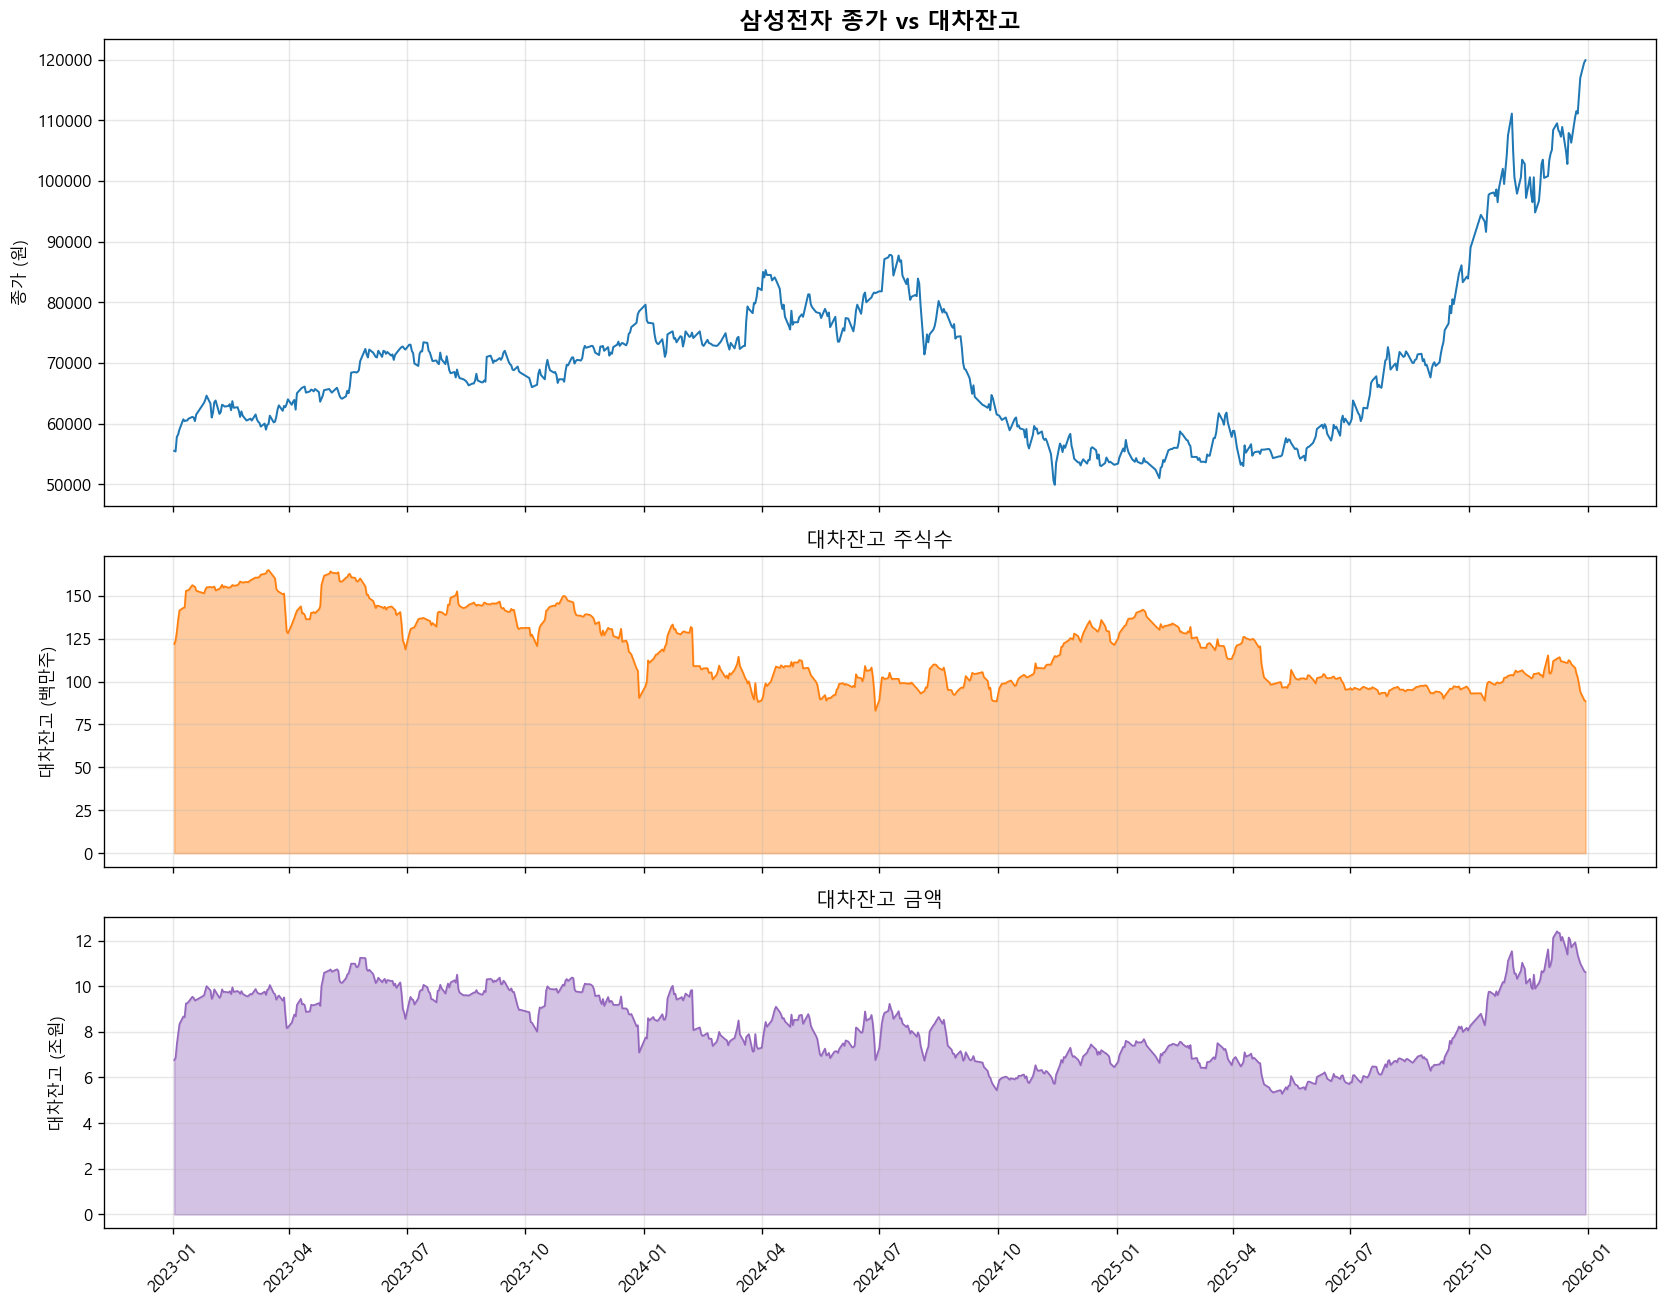

In [32]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True,
                         gridspec_kw={'height_ratios': [1.5, 1, 1]})

# (1) 종가
axes[0].plot(df2.index, df2['종가'], color='#1f77b4', linewidth=1.2)
axes[0].set_title('삼성전자 종가 vs 대차잔고', fontsize=14, fontweight='bold')
axes[0].set_ylabel('종가 (원)')
axes[0].grid(alpha=0.3)

# (2) 대차잔고 주식수
axes[1].fill_between(df2.index, df2['대차잔고주식수'] / 1e6, alpha=0.4, color='#ff7f0e')
axes[1].plot(df2.index, df2['대차잔고주식수'] / 1e6, color='#ff7f0e', linewidth=1)
axes[1].set_ylabel('대차잔고 (백만주)')
axes[1].set_title('대차잔고 주식수', fontsize=12)
axes[1].grid(alpha=0.3)

# (3) 대차잔고 금액
axes[2].fill_between(df2.index, df2['대차잔고금액'] / 1e12, alpha=0.4, color='#9467bd')
axes[2].plot(df2.index, df2['대차잔고금액'] / 1e12, color='#9467bd', linewidth=1)
axes[2].set_ylabel('대차잔고 (조원)')
axes[2].set_title('대차잔고 금액', fontsize=12)
axes[2].grid(alpha=0.3)

axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. 신용잔고금액 & 신용비율 추이 (종가 비교)

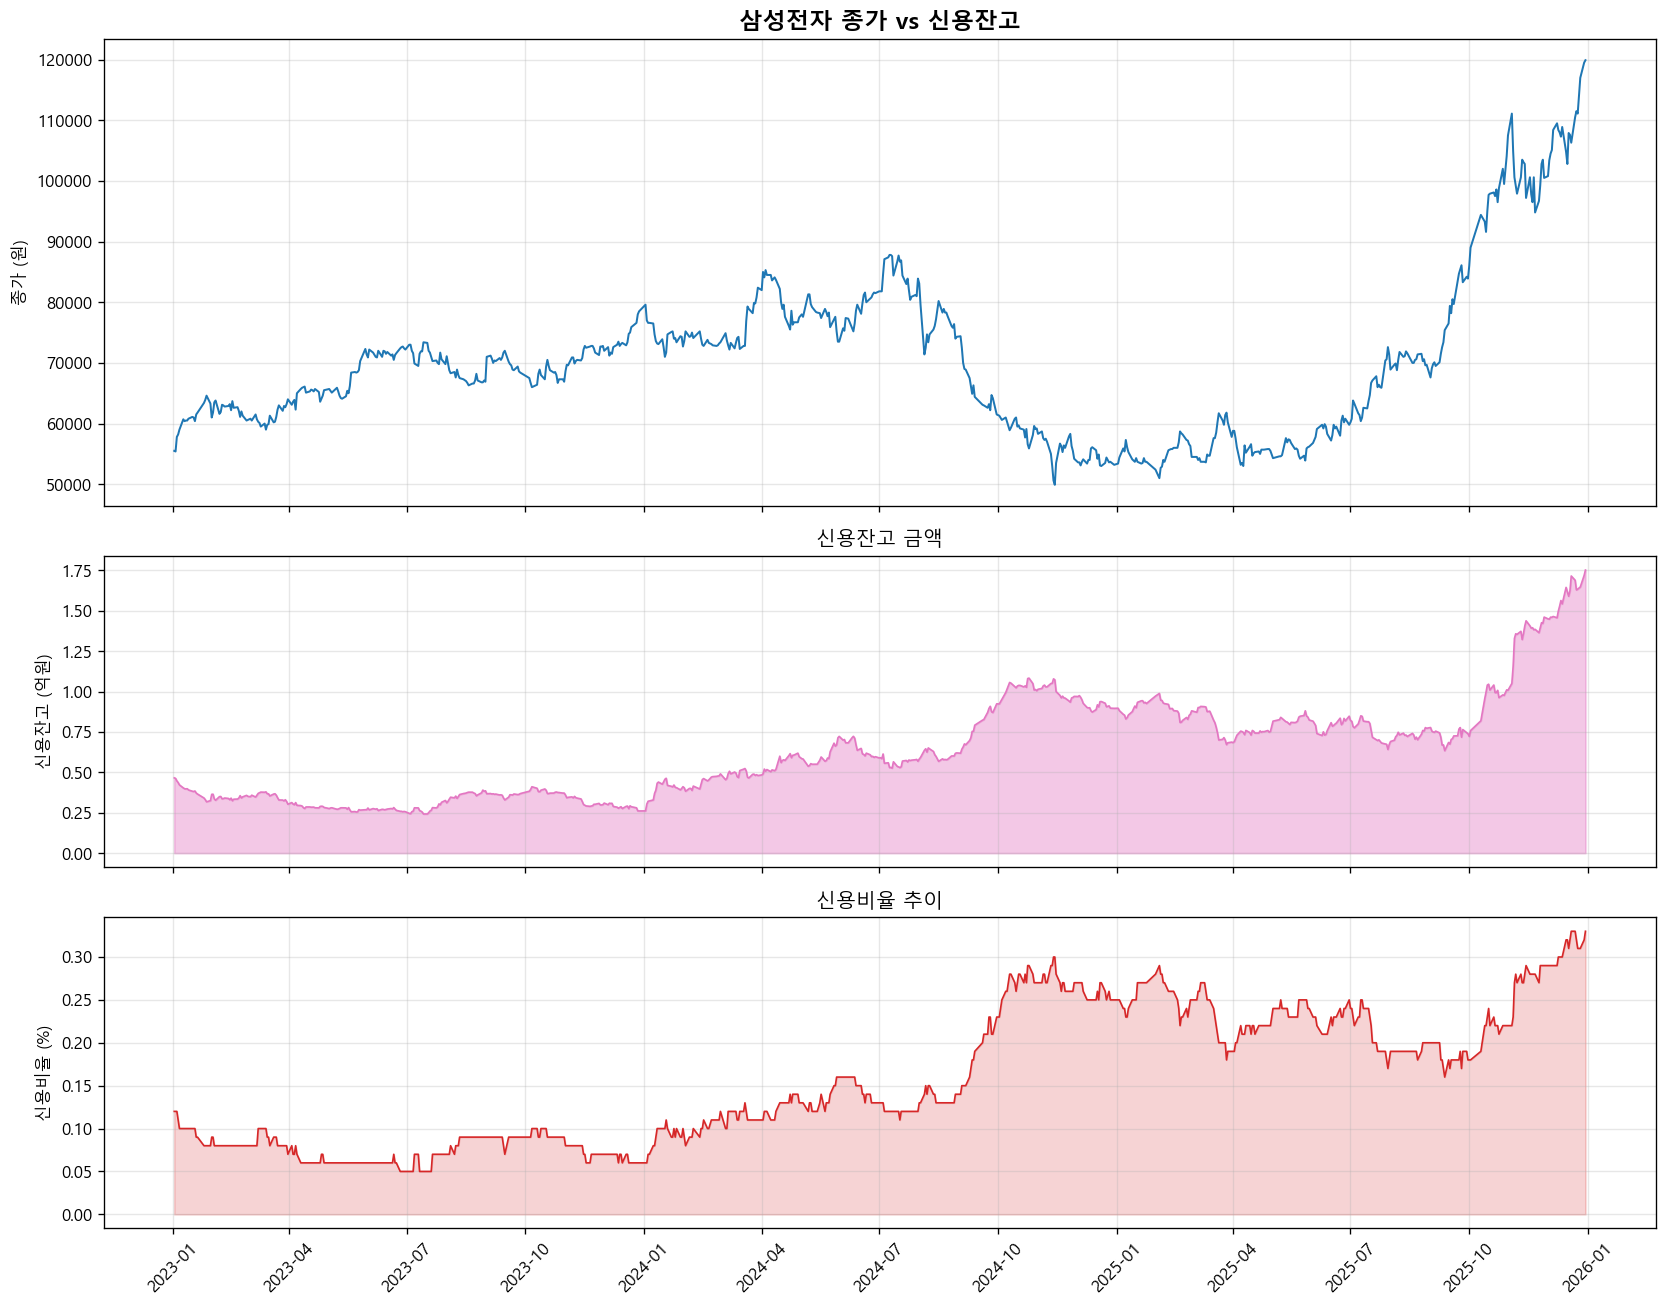

In [33]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True,
                         gridspec_kw={'height_ratios': [1.5, 1, 1]})

# (1) 종가
axes[0].plot(df2.index, df2['종가'], color='#1f77b4', linewidth=1.2)
axes[0].set_title('삼성전자 종가 vs 신용잔고', fontsize=14, fontweight='bold')
axes[0].set_ylabel('종가 (원)')
axes[0].grid(alpha=0.3)

# (2) 신용잔고 금액
axes[1].fill_between(df2.index, df2['신용잔고금액'] / 1e8, alpha=0.4, color='#e377c2')
axes[1].plot(df2.index, df2['신용잔고금액'] / 1e8, color='#e377c2', linewidth=1)
axes[1].set_ylabel('신용잔고 (억원)')
axes[1].set_title('신용잔고 금액', fontsize=12)
axes[1].grid(alpha=0.3)

# (3) 신용비율
axes[2].plot(df2.index, df2['신용비율'], color='#d62728', linewidth=1)
axes[2].fill_between(df2.index, df2['신용비율'], alpha=0.2, color='#d62728')
axes[2].set_ylabel('신용비율 (%)')
axes[2].set_title('신용비율 추이', fontsize=12)
axes[2].grid(alpha=0.3)

axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. 대차잔고 vs 신용잔고 이중축 비교

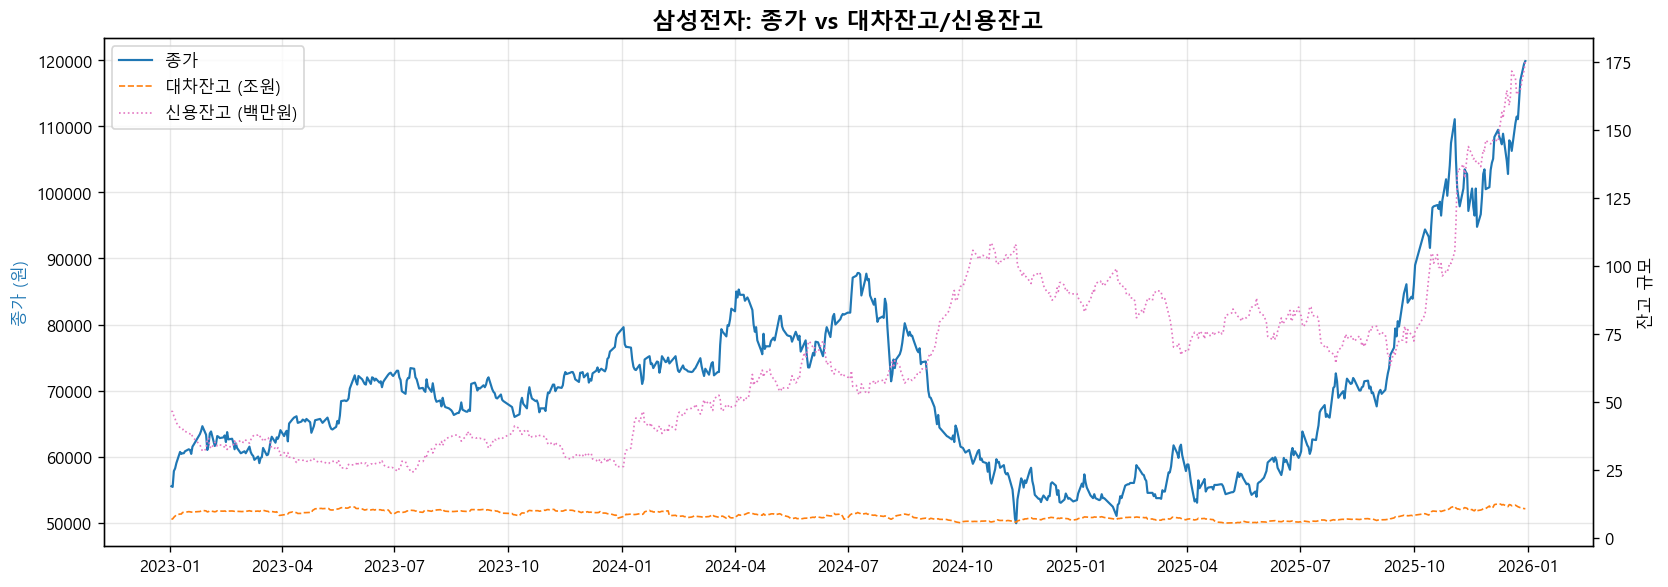

In [34]:
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(df2.index, df2['종가'], color='#1f77b4', linewidth=1.3, label='종가')
ax2.plot(df2.index, df2['대차잔고금액'] / 1e12, color='#ff7f0e', linewidth=1,
         linestyle='--', label='대차잔고 (조원)')
ax2.plot(df2.index, df2['신용잔고금액'] / 1e6, color='#e377c2', linewidth=1,
         linestyle=':', label='신용잔고 (백만원)')

ax1.set_ylabel('종가 (원)', color='#1f77b4')
ax2.set_ylabel('잔고 규모')
ax1.set_title('삼성전자: 종가 vs 대차잔고/신용잔고', fontsize=14, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 15. 대차/신용 지표 상관관계 히트맵

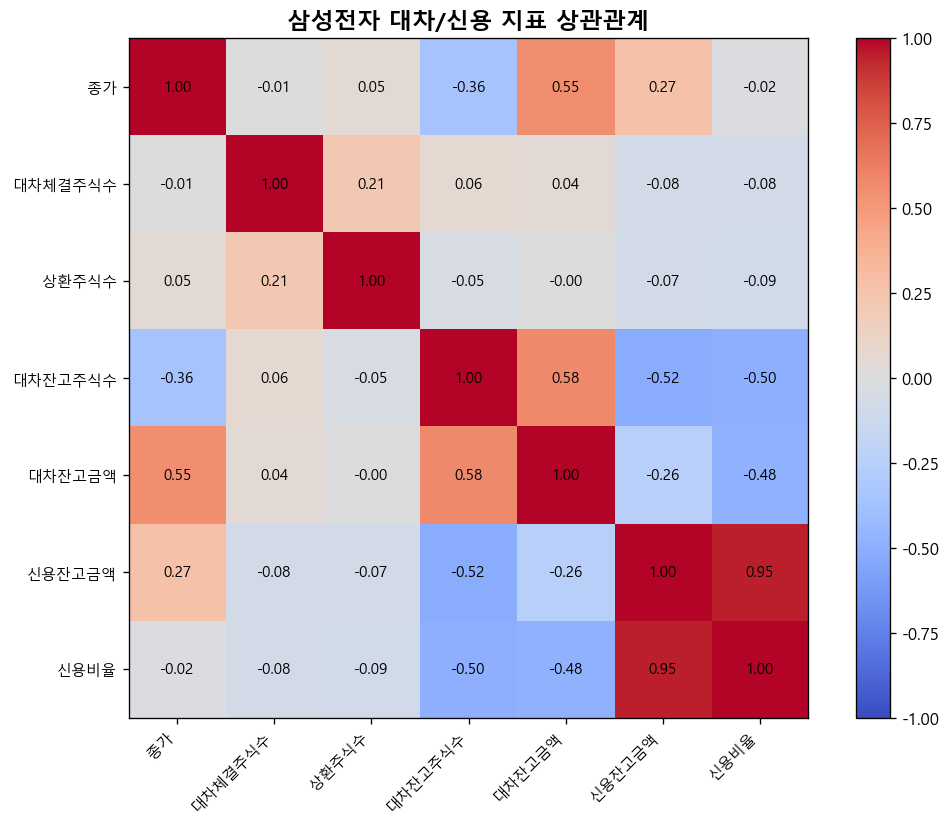

In [35]:
corr_cols2 = ['종가', '대차체결주식수', '상환주식수', '대차잔고주식수', '대차잔고금액', '신용잔고금액', '신용비율']
corr_matrix2 = df2[corr_cols2].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix2.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols2)))
ax.set_yticks(range(len(corr_cols2)))
ax.set_xticklabels(corr_cols2, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_cols2, fontsize=9)
plt.colorbar(im, ax=ax)

for i in range(len(corr_cols2)):
    for j in range(len(corr_cols2)):
        ax.text(j, i, f'{corr_matrix2.values[i, j]:.2f}', ha='center', va='center', fontsize=9)

ax.set_title('삼성전자 대차/신용 지표 상관관계', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. 대차/신용 요약 통계

In [36]:
print('='*60)
print('삼성전자 대차잔고 / 신용잔고 요약')
print('='*60)
print(f"\n--- 대차 ---")
print(f"  일평균 대차체결: {df2['대차체결주식수'].mean():,.0f}주")
print(f"  일평균 상환: {df2['상환주식수'].mean():,.0f}주")
print(f"  대차잔고 주식수 범위: {df2['대차잔고주식수'].min():,.0f}주 ~ {df2['대차잔고주식수'].max():,.0f}주")
print(f"  대차잔고 금액 범위: {df2['대차잔고금액'].min() / 1e12:,.2f}조원 ~ {df2['대차잔고금액'].max() / 1e12:,.2f}조원")
print(f"  최근 대차잔고: {df2['대차잔고주식수'].iloc[-1]:,.0f}주 ({df2['대차잔고금액'].iloc[-1] / 1e12:,.2f}조원)")
print(f"\n--- 신용 ---")
print(f"  신용잔고 금액 범위: {df2['신용잔고금액'].min() / 1e8:,.1f}억원 ~ {df2['신용잔고금액'].max() / 1e8:,.1f}억원")
print(f"  신용비율 범위: {df2['신용비율'].min():.2f}% ~ {df2['신용비율'].max():.2f}%")
print(f"  최근 신용비율: {df2['신용비율'].iloc[-1]:.2f}%")
print(f"  최근 신용잔고: {df2['신용잔고금액'].iloc[-1] / 1e8:,.1f}억원")

삼성전자 대차잔고 / 신용잔고 요약

--- 대차 ---
  일평균 대차체결: 2,396,151주
  일평균 상환: 2,441,486주
  대차잔고 주식수 범위: 83,020,315주 ~ 164,947,074주
  대차잔고 금액 범위: 5.29조원 ~ 12.41조원
  최근 대차잔고: 88,574,796주 (10.62조원)

--- 신용 ---
  신용잔고 금액 범위: 0.2억원 ~ 1.8억원
  신용비율 범위: 0.05% ~ 0.33%
  최근 신용비율: 0.33%
  최근 신용잔고: 1.8억원
